# Retail & Marketing Analytics Project

### Retail Sales Analysis with Seasonal Trends & Marketing Insights

This project focuses on analyzing retail sales data to identify seasonal sales trends, product movement patterns, packaging behavior, and operational inventory insights.

The workflow includes:
- Data cleaning and preprocessing
- Dataset segmentation
- Feature engineering
- Product packaging analysis
- Sales activity analysis
- Operational inventory analysis
- Exploratory data analysis (EDA)

## 1. Import Required Libraries

The required Python libraries are imported for:
- Data manipulation
- Data visualization
- Numerical computation
- Dataset downloading
- Regular expression processing

In [1]:
import os
import re
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Environment Configuration

Environment settings are configured to:
- Suppress unnecessary warnings
- Improve dataframe readability
- Configure visualization themes
- Standardize numeric display formatting

In [2]:
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

## 3. Dataset Download & Loading

The dataset is downloaded directly from KaggleHub and loaded into a Pandas DataFrame for further analysis.

In [3]:
DATASET_NAME = (
    "abdullah0a/retail-sales-data-with-seasonal-trends-and-marketing"
)

dataset_path = kagglehub.dataset_download(DATASET_NAME)

print(f"\nDataset downloaded at : {dataset_path}")

files = os.listdir(dataset_path)

csv_file = next(
    (file for file in files if file.endswith(".csv")),
    None
)

if csv_file is None:
    raise FileNotFoundError("CSV file not found!")

file_path = os.path.join(dataset_path, csv_file)

df = pd.read_csv(file_path)

print(f"\nDataset loaded successfully : {csv_file}")


Dataset downloaded at : C:\Users\Lenovo\.cache\kagglehub\datasets\abdullah0a\retail-sales-data-with-seasonal-trends-and-marketing\versions\2

Dataset loaded successfully : Retail and wherehouse Sale.csv


## 4. Initial Data Inspection

Initial inspection is performed to understand:
- Dataset dimensions
- Column structure
- Data types
- Missing values
- Statistical distribution
- Overall dataset quality


In [4]:
print("\n" + "=" * 80)
print("INITIAL DATA INSPECTION")
print("=" * 80)

rows, columns = df.shape
print(f"\nDataset Shape : {rows:,} rows × {columns} columns")

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nDataset Information:")
df.info()

print("\nColumn Data Types:")
display(df.dtypes)

print("\nStatistical Summary:")
display(df.describe(include="all"))


INITIAL DATA INSPECTION

Dataset Shape : 30,000 rows × 9 columns

First 5 Rows:


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.00,2.00
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.00,4.00
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.00,1.00
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.00,1.00
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.00,0.00



Last 5 Rows:


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
29995,2020,3,"THE COUNTRY VINTNER, LLC DBA WINEBOW",352322,FORTALEZA ANEJO TEQUILA - 750ML,LIQUOR,0.33,0.00,0.00
29996,2020,3,OSLO ENTERPRISE,352324,DOMAINE BRICHOT BLANC - 750ML,WINE,0.00,0.00,0.00
29997,2020,3,OPICI FAMILY DISTRIBUTING OF MD,352354,LOTE 44 MALBEC - 750ML,WINE,0.00,0.00,6.00
29998,2020,3,CAMPARI AMERICA LLC,35238,SKYY VODKA - 1.75L,LIQUOR,329.04,302.00,0.00
29999,2020,3,"THE COUNTRY VINTNER, LLC DBA WINEBOW",352380,CH HAUT LA PEREYRE BORD BLANC - 750ML,WINE,0.00,0.00,1.00



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              30000 non-null  int64  
 1   MONTH             30000 non-null  int64  
 2   SUPPLIER          29967 non-null  object 
 3   ITEM CODE         30000 non-null  object 
 4   ITEM DESCRIPTION  30000 non-null  object 
 5   ITEM TYPE         30000 non-null  object 
 6   RETAIL SALES      29999 non-null  float64
 7   RETAIL TRANSFERS  30000 non-null  float64
 8   WAREHOUSE SALES   30000 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.1+ MB

Column Data Types:


YEAR                  int64
MONTH                 int64
SUPPLIER             object
ITEM CODE            object
ITEM DESCRIPTION     object
ITEM TYPE            object
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object


Statistical Summary:


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,30000.00,30000.00,29967,30000,30000,30000,29999.00,30000.00,30000.00
unique,NaN,NaN,290,15668,15732,8,NaN,NaN,NaN
top,NaN,NaN,"THE COUNTRY VINTNER, LLC DBA WINEBOW",14206,TENTH WARD DIST CO CARAWAY RYE - 750ML,WINE,NaN,NaN,NaN
freq,NaN,NaN,2041,4,5,18680,NaN,NaN,NaN
mean,2020.00,3.91,NaN,NaN,NaN,NaN,6.94,6.59,27.43
std,0.00,2.84,NaN,NaN,NaN,NaN,33.08,27.88,272.17
min,2020.00,1.00,NaN,NaN,NaN,NaN,-0.42,-6.00,-3999.00
25%,2020.00,1.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00
50%,2020.00,3.00,NaN,NaN,NaN,NaN,0.16,0.00,1.00
75%,2020.00,7.00,NaN,NaN,NaN,NaN,2.92,3.00,6.00


## 5. Data Cleaning & Preprocessing

Data cleaning is performed to:
- Standardize column names
- Remove invalid records
- Handle missing values
- Validate data types
- Inspect duplicate records
- Analyze negative sales movements

In [5]:
print("\n" + "=" * 80)
print("DATA CLEANING")
print("=" * 80)


# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print("\nColumn names standardized successfully!")


# Unique value analysis
print("\nUnique Values in Each Column:")

for column in df.columns:
    print(f"{column:<20} : {df[column].nunique()}")


# Duplicate record check
duplicate_count = df.duplicated().sum()

print(f"\nDuplicate Records : {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed successfully!")


# Missing value summary
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percent
})

print("\nMissing Value Summary:")
display(missing_summary)


# Inspect missing retail_sales records
print("\nRows with Missing retail_sales:")

display(
    df[df["retail_sales"].isnull()]
)


# Observation:
# RMS ITEM is a system-generated placeholder record
# with no meaningful sales information.
# Hence, these rows are removed.

df = df[df["item_description"] != "RMS ITEM"].copy()

print("\nRMS ITEM rows removed successfully!")


# Inspect missing supplier records
print("\nRows with Missing supplier Values:")

display(
    df[df["supplier"].isnull()]
)


# Observation:
# Missing supplier values are replaced with 'UNKNOWN'
# to retain valid product records for analysis.

df["supplier"] = df["supplier"].fillna("UNKNOWN")

print("\nMissing supplier values filled successfully!")


print("\nMissing Values After Treatment:")
display(df.isnull().sum())


# Remove REF records
# REF contains credit/adjustment records and not actual product sales.

df = df[df["item_type"] != "REF"].copy()

print("\nREF rows removed successfully!")


# Check non-numeric item codes
invalid_codes = df[
    pd.to_numeric(df["item_code"], errors="coerce").isnull()
]

print("\nNon-numeric Item Codes After Removing REF Rows:")

display(
    invalid_codes[
        ["item_code", "item_description", "item_type"]
    ]
)


# Convert item_code to integer
df["item_code"] = pd.to_numeric(
    df["item_code"],
    errors="coerce"
).astype("Int64")

print("\nitem_code converted to integer successfully!")


print("\nData Types After Cleaning:")
display(df.dtypes)


# Negative value analysis
sales_columns = [
    "retail_sales",
    "retail_transfers",
    "warehouse_sales"
]

print("\nNegative Value Check:")

for column in sales_columns:
    negative_count = (df[column] < 0).sum()
    print(f"{column:<20} : {negative_count}")


# Observation:
# Negative values likely represent product returns,
# credit adjustments, or reverse inventory movements.
# Hence, negative records are retained for business analysis.

print("\nUnique Item Types After Cleaning:")
print(df["item_type"].unique())


DATA CLEANING

Column names standardized successfully!

Unique Values in Each Column:
year                 : 1
month                : 4
supplier             : 290
item_code            : 15668
item_description     : 15732
item_type            : 8
retail_sales         : 3657
retail_transfers     : 542
warehouse_sales      : 1032

Duplicate Records : 0

Missing Value Summary:


,missing_count,missing_percentage
year,0,0.00
month,0,0.00
supplier,33,0.11
item_code,0,0.00
item_description,0,0.00
item_type,0,0.00
retail_sales,1,0.00
retail_transfers,0,0.00
warehouse_sales,0,0.00



Rows with Missing retail_sales:


,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales
18390,2020,7,NaN,4,RMS ITEM,NON-ALCOHOL,NaN,0.00,0.00



RMS ITEM rows removed successfully!

Rows with Missing supplier Values:


...


REF rows removed successfully!

Non-numeric Item Codes After Removing REF Rows:


,item_code,item_description,item_type



item_code converted to integer successfully!

Data Types After Cleaning:


year                  int64
month                 int64
supplier             object
item_code             Int64
item_description     object
item_type            object
retail_sales        float64
retail_transfers    float64
warehouse_sales     float64
dtype: object


Negative Value Check:
retail_sales         : 5
retail_transfers     : 16
warehouse_sales      : 72

Unique Item Types After Cleaning:
['WINE' 'BEER' 'LIQUOR' 'STR_SUPPLIES' 'KEGS' 'DUNNAGE' 'NON-ALCOHOL']


## 6. Dataset Segmentation

The cleaned dataset is segmented into separate business categories for focused analysis:

- Alcohol Products
- Non-Alcohol Products
- Operational Inventory Products

This improves analytical clarity and enables category-specific feature engineering.

In [6]:
# Observation:
# The dataset is segmented into alcohol, non-alcohol,
# and operational categories for focused business analysis.


alcohol_df = df[
    df["item_type"].isin(["WINE", "BEER", "LIQUOR"])
].copy()

non_alcohol_df = df[
    df["item_type"] == "NON-ALCOHOL"
].copy()

operational_df = df[
    df["item_type"].isin(["STR_SUPPLIES", "KEGS", "DUNNAGE"])
].copy()

print("\nDataset segmentation completed successfully!")

print("\nDataset Shapes:")

print(f"Cleaned Master Data   : {df.shape}")
print(f"Alcohol Data          : {alcohol_df.shape}")
print(f"Non-Alcohol Data      : {non_alcohol_df.shape}")
print(f"Operational Data      : {operational_df.shape}")


Dataset segmentation completed successfully!

Dataset Shapes:
Cleaned Master Data   : (29991, 9)
Alcohol Data          : (28892, 9)
Non-Alcohol Data      : (215, 9)
Operational Data      : (884, 9)


## 7. Common Analytical Helper Functions

Reusable helper functions are created to:
- Calculate total sales movement
- Generate quarterly features
- Standardize analytical logic across segmented datasets

This reduces code duplication and improves maintainability.

In [7]:
# Common helper functions for segmented datasets

def add_sales_features(data):
    data = data.copy()

    data["total_sales"] = (
        data["retail_sales"] +
        data["retail_transfers"] +
        data["warehouse_sales"]
    )

    data["quarter"] = (
        ((data["month"] - 1) // 3) + 1
    )

    return data


def classify_sales_activity(value):
    if value == 0:
        return "NO_SALES"
    elif value < 100:
        return "LOW"
    elif value < 1000:
        return "MEDIUM"
    else:
        return "HIGH"

## 8. Alcohol Product Feature Engineering

Alcohol product descriptions contain embedded bottle and packaging information in inconsistent formats.

Feature engineering is applied to:
- Extract bottle/package sizes
- Standardize product descriptions
- Create bottle size categories
- Generate sales activity features
- Prepare the dataset for advanced sales analysis

In [8]:
print("\n" + "=" * 80)
print("ALCOHOL PRODUCT FEATURE ENGINEERING")
print("=" * 80)


alcohol_df["original_description"] = alcohol_df["item_description"]

alcohol_df["item_description"] = (
    alcohol_df["item_description"]
      .str.replace(r"\s*-\s*", " - ", regex=True)
)

size_pattern = (
    r"("
    r"\d+\.?\d*\s?(ML|L|LITER|OZ|Z|PK|PACK|CANS?|CAN|NR|K|KEG)"
    r"|"
    r"\d+/\d+\s?(NR|CN|CANS?|PK)?"
    r"|"
    r"\b(375|750|1750|1\.75|250)\b"
    r")"
)

alcohol_df["bottle_size"] = (
    alcohol_df["item_description"]
      .str.extract(size_pattern, flags=re.IGNORECASE, expand=False)[0]
)

alcohol_df["bottle_size"] = (
    alcohol_df["bottle_size"]
      .str.upper()
      .str.replace(r"\s+", "", regex=True)
      .replace({
          "375": "375ML",
          "750": "750ML",
          "1750": "1.75L",
          "250": "250ML",
          "LITER": "1L",
          "0750ML": "750ML",
          "1.0L": "1L"
      })
)

mask = (
    alcohol_df["bottle_size"].isnull()
    &
    alcohol_df["item_description"].str.contains("LITER", case=False, na=False)
)

alcohol_df.loc[mask, "bottle_size"] = "1L"

alcohol_df["item_description"] = (
    alcohol_df["item_description"]
      .str.replace(size_pattern, "", flags=re.IGNORECASE, regex=True)
      .str.replace(r"\s*-\s*(NR|CAN|CANS)$", "", regex=True)
      .str.replace(r"\(SEAS\)", "", regex=True)
      .str.replace(r"\s*-\s*$", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

alcohol_df["bottle_size"] = alcohol_df["bottle_size"].fillna("UNKNOWN")


def categorize_bottle_size(size):

    if pd.isna(size):
        return "UNKNOWN"

    size = str(size)

    if "CANS" in size or "/" in size:
        return "MULTI_PACK"

    elif size in ["50ML", "100ML", "187ML", "200ML"]:
        return "SMALL"

    elif size in ["375ML", "500ML"]:
        return "MEDIUM"

    elif size in ["720ML", "750ML"]:
        return "STANDARD"

    elif size in ["1L", "1.5L", "1.75L", "3L"]:
        return "LARGE"

    else:
        return "OTHER"


alcohol_df["bottle_category"] = (
    alcohol_df["bottle_size"]
      .apply(categorize_bottle_size)
)

alcohol_df = add_sales_features(alcohol_df)

alcohol_df["sales_activity"] = (
    alcohol_df["total_sales"]
      .apply(classify_sales_activity)
)

print("\nAlcohol product features created successfully!")

display(
    alcohol_df[
        [
            "original_description",
            "item_description",
            "bottle_size",
            "bottle_category",
            "total_sales",
            "quarter",
            "sales_activity"
        ]
    ].head(20)
)


ALCOHOL PRODUCT FEATURE ENGINEERING

Alcohol product features created successfully!


,original_description,item_description,bottle_size,bottle_category,total_sales,quarter,sales_activity
0,BOOTLEG RED - 750ML,BOOTLEG RED,750ML,STANDARD,2.00,1,LOW
1,MOMENT DE PLAISIR - 750ML,MOMENT DE PLAISIR,750ML,STANDARD,5.00,1,LOW
2,S SMITH ORGANIC PEAR CIDER - 18.7OZ,S SMITH ORGANIC PEAR CIDER,18.7OZ,OTHER,1.00,1,LOW
3,SCHLINK HAUS KABINETT - 750ML,SCHLINK HAUS KABINETT,750ML,STANDARD,1.00,1,LOW
4,SANTORINI GAVALA WHITE - 750ML,SANTORINI GAVALA WHITE,750ML,STANDARD,0.82,1,LOW
5,CORTENOVA VENETO P/GRIG - 750ML,CORTENOVA VENETO P/GRIG,750ML,STANDARD,8.76,1,LOW
6,SANTA MARGHERITA P/GRIG ALTO - 375ML,SANTA MARGHERITA P/GRIG ALTO,375ML,MEDIUM,2.08,1,LOW
7,JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH -...,JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH,10.OZ,OTHER,2.00,1,LOW
8,KNOB CREEK BOURBON 9YR - 100P - 375ML,KNOB CREEK BOURBON 9YR - 100P,375ML,MEDIUM,10.41,1,LOW
9,KSARA CAB - 750ML,KSARA CAB,750ML,STANDARD,3.33,1,LOW


## 9. Non-Alcohol Product Feature Engineering

Non-alcohol product descriptions are processed separately because their packaging structures differ from alcohol products.

Feature engineering includes:
- Package size extraction
- Product description refinement
- Packaging standardization
- Sales feature generation

In [9]:
print("\n" + "=" * 80)
print("NON-ALCOHOL PRODUCT FEATURE ENGINEERING")
print("=" * 80)


non_alcohol_df["original_description"] = non_alcohol_df["item_description"]

non_alcohol_df["item_description"] = (
    non_alcohol_df["item_description"]
      .str.replace(r"\s*-\s*", " - ", regex=True)
)

package_size_pattern = (
    r"("
    r"\d+\.?\d*\s?(ML|L|LITER|OZ|Z|PK|PACK|CAN|CANS)"
    r"|"
    r"\b(375|750|1000)\b"
    r")"
)

non_alcohol_df["package_size"] = (
    non_alcohol_df["item_description"]
      .str.extract(package_size_pattern, flags=re.IGNORECASE, expand=False)[0]
)

non_alcohol_df["package_size"] = (
    non_alcohol_df["package_size"]
      .str.upper()
      .str.replace(r"\s+", "", regex=True)
      .replace({
          "750": "750ML",
          "1000": "1L",
          "LITER": "1L",
          "11.2Z": "11.2OZ",
          "170Z": "17OZ"
      })
)

non_alcohol_df["item_description"] = (
    non_alcohol_df["item_description"]
      .str.replace(package_size_pattern, "", flags=re.IGNORECASE, regex=True)
      .str.replace(r"\s*-\s*$", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

non_alcohol_df["package_size"] = non_alcohol_df["package_size"].fillna("UNKNOWN")

liter_mask = (
    non_alcohol_df["package_size"].eq("UNKNOWN")
    &
    non_alcohol_df["item_description"].str.contains("LITER", case=False, na=False)
)

non_alcohol_df.loc[liter_mask, "package_size"] = "1L"

multipack_mask = (
    non_alcohol_df["package_size"].eq("UNKNOWN")
    &
    non_alcohol_df["item_description"].str.contains(
        r"\d+/\d+\s?NR",
        case=False,
        na=False
    )
)

non_alcohol_df.loc[multipack_mask, "package_size"] = (
    non_alcohol_df.loc[multipack_mask, "item_description"]
      .str.extract(r"(\d+/\d+\s?NR)", expand=False)
      .str.replace(" ", "", regex=False)
      .str.upper()
)

non_alcohol_df = add_sales_features(non_alcohol_df)

print("\nNon-alcohol product features created successfully!")

display(
    non_alcohol_df[
        [
            "original_description",
            "item_description",
            "package_size",
            "total_sales",
            "quarter"
        ]
    ].head(20)
)


NON-ALCOHOL PRODUCT FEATURE ENGINEERING

Non-alcohol product features created successfully!


,original_description,item_description,package_size,total_sales,quarter
769,MASTER OF MIXES COCKTAIL ESSENTIALS SIMPLE SYR...,MASTER OF MIXES COCKTAIL ESSENTIALS SIMPLE SYR...,UNKNOWN,40.98,1
770,AGALIMA SWEET & SOUR MIX - 1L,AGALIMA SWEET & SOUR MIX,1L,11.13,1
771,AGALIMA MARGARITA MIX - 1L,AGALIMA MARGARITA MIX,1L,29.56,1
793,ARIEL CHARD NON ALCOHOLIC - 750ML,ARIEL CHARD NON ALCOHOLIC,750ML,12.16,1
981,ICE,ICE,UNKNOWN,542.00,1
1015,Q DRINKS GINGER ALE NA - 6.7OZ,Q DRINKS GINGER ALE NA,6.7OZ,3.00,1
2115,FINEST CALL LIME JUICE - 1L,FINEST CALL LIME JUICE,1L,1.00,1
2702,ZURENA LOVE ELIXIR CRAFT COCKTAIL MIXER - 750ML,ZURENA LOVE ELIXIR CRAFT COCKTAIL MIXER,750ML,4.42,1
2733,SUTTER HOME FRE' PREMIUM RED - 750ML,SUTTER HOME FRE' PREMIUM RED,750ML,3.00,1
3136,REGAN ORANGE BITTER 12/CS - 5OZ,REGAN ORANGE BITTER 12/CS,5OZ,16.83,1


## 10. Feature Engineering Validation

Validation checks are performed to verify:
- Dataset integrity
- Feature distributions
- Unknown package values
- Sales activity categories
- Overall feature engineering quality

In [10]:
# =============================================================================
# FINAL FEATURE ENGINEERING VALIDATION
# =============================================================================

print("\n" + "=" * 80)
print("FINAL FEATURE ENGINEERING VALIDATION")
print("=" * 80)


# Alcohol dataset validation
print("\nAlcohol Dataset Shape:")
print(alcohol_df.shape)


print("\nAlcohol Bottle Category Distribution:")

display(
    alcohol_df["bottle_category"]
      .value_counts()
)


print("\nAlcohol Sales Activity Distribution:")

display(
    alcohol_df["sales_activity"]
      .value_counts()
)


print(
    "\nAlcohol UNKNOWN Bottle Sizes :",
    (
        alcohol_df["bottle_size"]
          .eq("UNKNOWN")
          .sum()
    )
)


# Non-alcohol dataset validation
print("\nNon-Alcohol Dataset Shape:")
print(non_alcohol_df.shape)


print("\nNon-Alcohol Package Size Distribution:")

display(
    non_alcohol_df["package_size"]
      .value_counts()
)


print(
    "\nNon-Alcohol UNKNOWN Package Sizes :",
    (
        non_alcohol_df["package_size"]
          .eq("UNKNOWN")
          .sum()
    )
)


print("\nFeature engineering validation completed successfully!")


FINAL FEATURE ENGINEERING VALIDATION

Alcohol Dataset Shape:
(28892, 15)

Alcohol Bottle Category Distribution:


bottle_category
STANDARD      19783
MULTI_PACK     3393
LARGE          2740
OTHER          1566
MEDIUM          799
SMALL           611
Name: count, dtype: int64


Alcohol Sales Activity Distribution:


sales_activity
LOW         26924
MEDIUM       1745
HIGH          160
NO_SALES       63
Name: count, dtype: int64


Alcohol UNKNOWN Bottle Sizes : 183

Non-Alcohol Dataset Shape:
(215, 13)

Non-Alcohol Package Size Distribution:


package_size
1L         44
750ML      32
12OZ       17
1.75L      17
32OZ       13
UNKNOWN    11
4PK        10
8OZ         9
5OZ         6
6L          6
17OZ        6
6CAN        6
11.2OZ      6
6.7OZ       5
375ML       4
4OZ         3
16OZ        3
3.5OZ       3
200ML       2
4CAN        2
6/4NR       2
500ML       2
51OZ        2
251ML       2
5PK         2
Name: count, dtype: int64


Non-Alcohol UNKNOWN Package Sizes : 11

Feature engineering validation completed successfully!


## 11. Operational Product Feature Engineering

Operational inventory products such as:
- Kegs
- Dunnage
- Store supplies

are processed separately because they represent operational inventory movement rather than direct consumer retail products.

Feature engineering includes:
- Keg/package extraction
- Operational activity classification
- Inventory movement analysis

In [11]:
print("\n" + "=" * 80)
print("OPERATIONAL PRODUCT FEATURE ENGINEERING")
print("=" * 80)


# Backup original descriptions
operational_df["original_description"] = (
    operational_df["item_description"]
)


# Standardize spacing around hyphens
operational_df["item_description"] = (
    operational_df["item_description"]
      .str.replace(r"\s*-\s*", " - ", regex=True)
)


# Keg/package size pattern
operational_pattern = (
    r"("
    r"\d+/?\d*\s?(K|KEG|L|PACK)"
    r"|"
    r"\d+/\d+\s?(K|KEG)?"
    r")"
)


# Extract keg/package size
operational_df["package_size"] = (
    operational_df["item_description"]
      .str.extract(
          operational_pattern,
          flags=re.IGNORECASE,
          expand=False
      )[0]
)


# Standardize package sizes
operational_df["package_size"] = (
    operational_df["package_size"]
      .str.upper()
      .str.replace(r"\s+", "", regex=True)
)


# Remove extracted package size from descriptions
operational_df["item_description"] = (
    operational_df["item_description"]
      .str.replace(
          operational_pattern,
          "",
          flags=re.IGNORECASE,
          regex=True
      )
      .str.replace(r"\s*-\s*$", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)


# Fill unavailable package sizes
operational_df["package_size"] = (
    operational_df["package_size"]
      .fillna("UNKNOWN")
)


# Create total operational movement feature
operational_df = add_sales_features(operational_df)


# Create operational activity category
def classify_operational_activity(value):

    if value == 0:
        return "NO_ACTIVITY"

    elif value < 10:
        return "LOW"

    elif value < 100:
        return "MEDIUM"

    else:
        return "HIGH"


operational_df["operational_activity"] = (
    operational_df["total_sales"]
      .abs()
      .apply(classify_operational_activity)
)


print("\nOperational product features created successfully!")


# Sample validation
print("\nSample Operational Records:")

display(
    operational_df[
        [
            "original_description",
            "item_description",
            "package_size",
            "total_sales",
            "quarter",
            "operational_activity"
        ]
    ].head(20)
)


# Package size distribution
print("\nOperational Package Size Distribution:")

display(
    operational_df["package_size"]
      .value_counts()
)


# Operational activity distribution
print("\nOperational Activity Distribution:")

display(
    operational_df["operational_activity"]
      .value_counts()
)


# Final dataset shape
print("\nFinal Operational Dataset Shape:")
print(operational_df.shape)


OPERATIONAL PRODUCT FEATURE ENGINEERING

Operational product features created successfully!

Sample Operational Records:


,original_description,item_description,package_size,total_sales,quarter,operational_activity
24,TWO BOTTLE WINE TOTE,TWO BOTTLE WINE TOTE,UNKNOWN,0.10,1,LOW
46,FIRESTONE NITRO MERLIN - 50L,FIRESTONE NITRO MERLIN,50L,1.00,1,LOW
48,FOUR BOTTLE WINE TOTE,FOUR BOTTLE WINE TOTE,UNKNOWN,0.40,1,LOW
77,WINE GIFT TOTE SINGLE BOTTLE,WINE GIFT TOTE SINGLE BOTTLE,UNKNOWN,10.60,1,MEDIUM
83,ALHAMBRA RESERVA 20L-1/6K,ALHAMBRA RESERVA,20L,1.00,1,LOW
85,SIX BOTTLE WINE TOTE (NO LOGO),SIX BOTTLE WINE TOTE (NO LOGO),UNKNOWN,8.10,1,LOW
89,FIRESTONE LUPONIC DISTORTION - 50L,FIRESTONE LUPONIC DISTORTION,50L,2.00,1,LOW
106,JIGGER MEASURE SHOT GLASS,JIGGER MEASURE SHOT GLASS,UNKNOWN,32.69,1,MEDIUM
120,SIERRA NEVADA KELLERWEIS - 1/6K,SIERRA NEVADA KELLERWEIS,1/6K,1.00,1,LOW
135,WINE TOTE WOOD HANDLE 2 POCKET 4 BTL,WINE TOTE WOOD HANDLE 2 POCKET 4 BTL,UNKNOWN,2.80,1,LOW



Operational Package Size Distribution:


package_size
1/2K       465
1/6K       253
UNKNOWN     60
50L         39
1/4K        29
20L         17
1/6          7
30L          6
1/2          4
12L          2
1969L        1
5L           1
Name: count, dtype: int64


Operational Activity Distribution:


operational_activity
LOW            664
MEDIUM         186
HIGH            24
NO_ACTIVITY     10
Name: count, dtype: int64


Final Operational Dataset Shape:
(884, 14)


## 12. Export Processed Datasets

The cleaned and feature-engineered datasets are exported as CSV files for:
- Further analysis
- Visualization
- Dashboard development
- Reporting
- Future machine learning workflows

Separate datasets are maintained for:
- Master retail dataset
- Alcohol products
- Non-alcohol products
- Operational inventory products

In [12]:
# Export processed datasets

os.makedirs("processed_data", exist_ok=True)

df.to_csv("processed_data/cleaned_master_data.csv", index=False)

alcohol_df.to_csv("processed_data/alcohol_data_processed.csv", index=False)

non_alcohol_df.to_csv("processed_data/non_alcohol_data_processed.csv", index=False)

operational_df.to_csv("processed_data/operational_data_processed.csv", index=False)

print("\nProcessed datasets exported successfully!")

print("\nExported Dataset Shapes:")
print(f"Master Dataset       : {df.shape}")
print(f"Alcohol Dataset      : {alcohol_df.shape}")
print(f"Non-Alcohol Dataset  : {non_alcohol_df.shape}")
print(f"Operational Dataset  : {operational_df.shape}")


Processed datasets exported successfully!

Exported Dataset Shapes:
Master Dataset       : (29991, 9)
Alcohol Dataset      : (28892, 15)
Non-Alcohol Dataset  : (215, 13)
Operational Dataset  : (884, 14)


In [13]:
alcohol_df.head()

,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales,original_description,bottle_size,bottle_category,total_sales,quarter,sales_activity
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED,WINE,0.00,0.00,2.00,BOOTLEG RED - 750ML,750ML,STANDARD,2.00,1,LOW
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR,WINE,0.00,1.00,4.00,MOMENT DE PLAISIR - 750ML,750ML,STANDARD,5.00,1,LOW
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER,BEER,0.00,0.00,1.00,S SMITH ORGANIC PEAR CIDER - 18.7OZ,18.7OZ,OTHER,1.00,1,LOW
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT,WINE,0.00,0.00,1.00,SCHLINK HAUS KABINETT - 750ML,750ML,STANDARD,1.00,1,LOW
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE,WINE,0.82,0.00,0.00,SANTORINI GAVALA WHITE - 750ML,750ML,STANDARD,0.82,1,LOW


In [14]:
non_alcohol_df.head()

,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales,original_description,package_size,total_sales,quarter
769,2020,1,AMERICAN BEVERAGE MARKETERS,166661,MASTER OF MIXES COCKTAIL ESSENTIALS SIMPLE SYR...,NON-ALCOHOL,17.98,23.00,0.00,MASTER OF MIXES COCKTAIL ESSENTIALS SIMPLE SYR...,UNKNOWN,40.98,1
770,2020,1,AMERICAN BEVERAGE MARKETERS,166662,AGALIMA SWEET & SOUR MIX,NON-ALCOHOL,7.13,4.00,0.00,AGALIMA SWEET & SOUR MIX - 1L,1L,11.13,1
771,2020,1,AMERICAN BEVERAGE MARKETERS,166663,AGALIMA MARGARITA MIX,NON-ALCOHOL,15.73,13.83,0.00,AGALIMA MARGARITA MIX - 1L,1L,29.56,1
793,2020,1,RELIABLE CHURCHILL LLLP,169161,ARIEL CHARD NON ALCOHOLIC,NON-ALCOHOL,3.16,5.00,4.00,ARIEL CHARD NON ALCOHOLIC - 750ML,750ML,12.16,1
981,2020,1,UNKNOWN,2,ICE,NON-ALCOHOL,542.00,0.00,0.00,ICE,UNKNOWN,542.00,1


In [15]:
operational_df.head()

,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales,original_description,package_size,total_sales,quarter,operational_activity
24,2020,1,Default,102,TWO BOTTLE WINE TOTE,STR_SUPPLIES,0.10,0.00,0.00,TWO BOTTLE WINE TOTE,UNKNOWN,0.10,1,LOW
46,2020,1,LEGENDS LTD,10387,FIRESTONE NITRO MERLIN,KEGS,0.00,0.00,1.00,FIRESTONE NITRO MERLIN - 50L,50L,1.00,1,LOW
48,2020,1,Default,104,FOUR BOTTLE WINE TOTE,STR_SUPPLIES,0.40,0.00,0.00,FOUR BOTTLE WINE TOTE,UNKNOWN,0.40,1,LOW
77,2020,1,Default,105,WINE GIFT TOTE SINGLE BOTTLE,STR_SUPPLIES,10.60,0.00,0.00,WINE GIFT TOTE SINGLE BOTTLE,UNKNOWN,10.60,1,MEDIUM
83,2020,1,LEGENDS LTD,10586,ALHAMBRA RESERVA,KEGS,0.00,0.00,1.00,ALHAMBRA RESERVA 20L-1/6K,20L,1.00,1,LOW


# Alcohol Product Exploratory Data Analysis (EDA)

EDA is performed on alcohol products to analyze:
- Sales trends
- Bottle size behavior
- Product category movement
- Supplier contribution
- Seasonal demand patterns

## Sales Trend Analysis

Sales trend analysis is performed to identify:
- Monthly sales fluctuations
- Quarter-wise sales movement
- Seasonal demand behavior
- Overall alcohol sales performance

### Monthly & Quarterly Sales Trend Analysis

The available dataset contains sales records for selected months:
- January
- March
- July
- September

Sales trend analysis is performed to identify:
- Monthly sales fluctuations
- Quarter-wise sales movement
- Relative seasonal demand behavior
- Overall alcohol sales performance across available periods

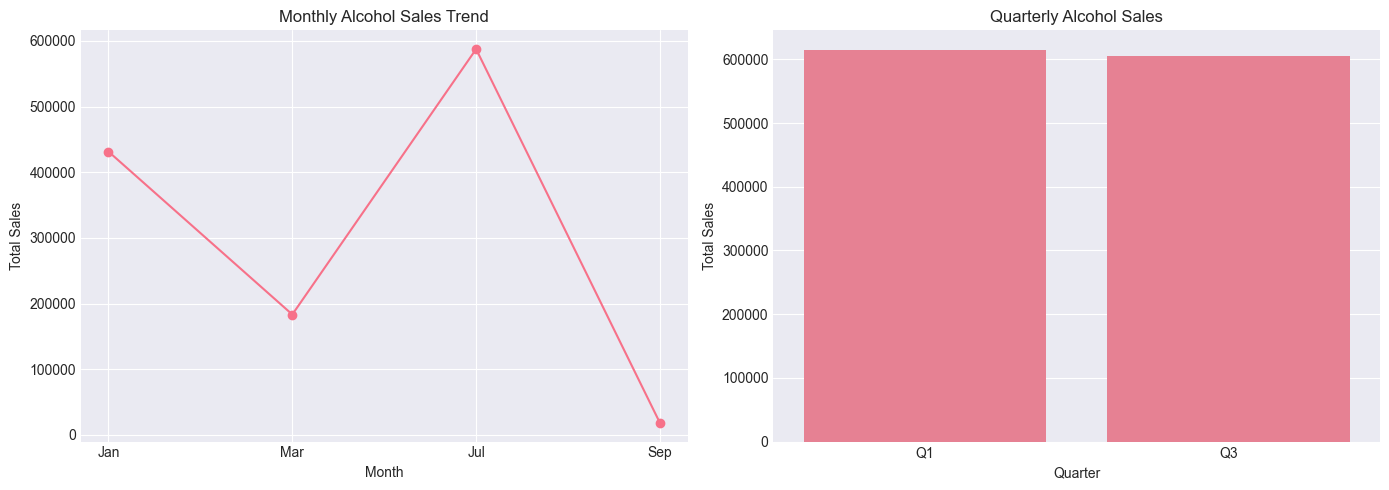

In [16]:
month_map = {1: "Jan", 3: "Mar", 7: "Jul", 9: "Sep"}

monthly_sales = alcohol_df.groupby("month")["total_sales"].sum().reset_index()
monthly_sales["month_name"] = monthly_sales["month"].map(month_map)

quarterly_sales = alcohol_df.groupby("quarter")["total_sales"].sum().reset_index()
quarterly_sales["quarter_name"] = "Q" + quarterly_sales["quarter"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_sales["month_name"], monthly_sales["total_sales"], marker="o")
axes[0].set_title("Monthly Alcohol Sales Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Sales")

sns.barplot(data=quarterly_sales, x="quarter_name", y="total_sales", ax=axes[1])
axes[1].set_title("Quarterly Alcohol Sales")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Key Findings

- July recorded the highest alcohol sales among the available months.
- September showed a significant decline in alcohol sales compared to other months.
- Alcohol sales fluctuated noticeably across the recorded periods, indicating varying demand behavior.
- Quarter 1 and Quarter 3 contributed almost equally to total alcohol sales.
- Overall sales distribution suggests relatively balanced performance between the available quarters.

### Product Category Movement Analysis

Product category analysis is performed to understand:
- Sales contribution by alcohol category
- Dominant product segments
- Product movement distribution across Wine, Beer, and Liquor

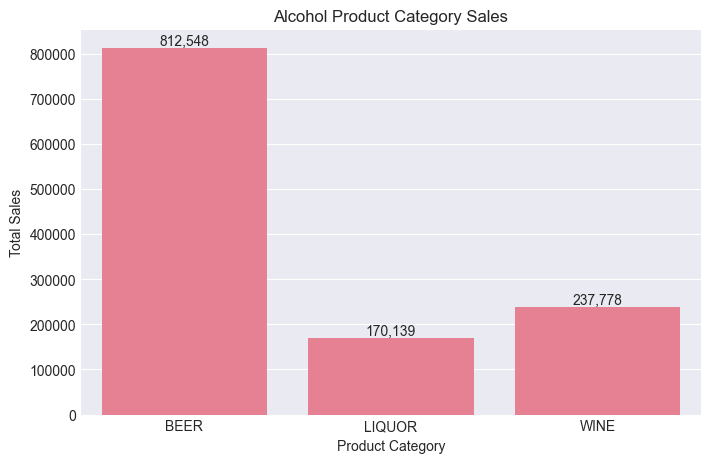

In [17]:
item_type_sales = alcohol_df.groupby("item_type")["total_sales"].sum().reset_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(data=item_type_sales, x="item_type", y="total_sales")

for i, value in enumerate(item_type_sales["total_sales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.title("Alcohol Product Category Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

### Key Findings

- Beer products generated the highest alcohol sales by a significant margin.
- Wine products contributed moderately to total alcohol sales.
- Liquor products recorded the lowest sales among the alcohol categories.
- The sales distribution indicates strong customer demand for beer products compared to other alcohol segments.

### Bottle Size Behavior Analysis

Bottle size analysis is performed to understand:
- Packaging preferences
- Multi-pack demand behavior
- Standard bottle dominance
- Product movement across bottle categories

### Bottle Category Definition

Bottle/package sizes are grouped into broader business categories for simplified analysis and better business interpretation.

- SMALL → 50ML, 100ML, 187ML, 200ML
- MEDIUM → 375ML, 500ML
- STANDARD → 720ML, 750ML
- LARGE → 1L, 1.5L, 1.75L, 3L
- MULTI_PACK → Products containing multiple cans/bottles such as 4/6CANS, 6/4NR, and similar packaging patterns
- OTHER → Rare, irregular, or less frequent package sizes
- UNKNOWN → Products where bottle/package size information is unavailable

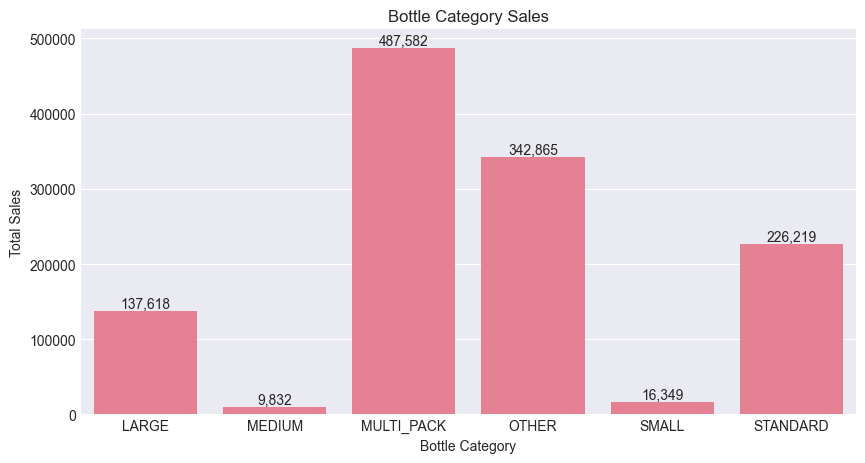

In [18]:
bottle_category_sales = alcohol_df.groupby("bottle_category")["total_sales"].sum().reset_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=bottle_category_sales, x="bottle_category", y="total_sales")

for i, value in enumerate(bottle_category_sales["total_sales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.title("Bottle Category Sales")
plt.xlabel("Bottle Category")
plt.ylabel("Total Sales")

plt.show()

### Key Findings

- Multi-pack products generated the highest alcohol sales among all bottle categories.
- Standard bottle categories also contributed significantly to overall sales performance.
- Large bottle categories showed moderate sales movement.
- Small and medium bottle categories contributed relatively lower sales.
- Customer purchasing behavior indicates strong demand for multi-pack and standard-sized alcohol packaging.

### Supplier Contribution Analysis

Supplier-level analysis is performed to identify:
- Top-performing suppliers
- Major contributors to alcohol sales
- Supplier sales concentration
- Product distribution behavior across suppliers

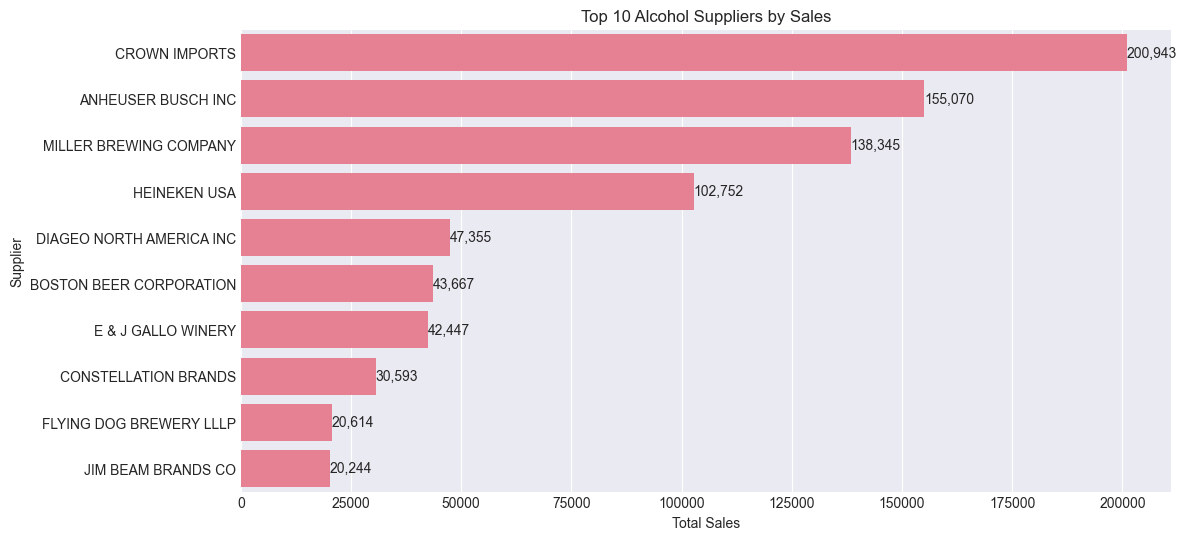

In [19]:
top_suppliers = (
    alcohol_df.groupby("supplier")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(data=top_suppliers, x="total_sales", y="supplier")

for i, value in enumerate(top_suppliers["total_sales"]):
    ax.text(value, i, f"{value:,.0f}", va="center")

plt.title("Top 10 Alcohol Suppliers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Supplier")

plt.show()

### Key Findings

- CROWN IMPORTS recorded the highest alcohol sales among all suppliers.
- ANHEUSER BUSCH INC and MILLER BREWING COMPANY were also major contributors to total alcohol sales.
- Sales contribution is highly concentrated among a few leading suppliers.
- Beer-focused suppliers dominate the top supplier rankings, indicating strong beer market demand.
- Lower-ranked suppliers contributed comparatively smaller sales volumes.

### Sales Activity Analysis

Sales activity analysis is performed to understand:
- Product movement intensity
- Distribution of low and high selling products
- Overall alcohol sales activity behavior
- Sales concentration across activity levels

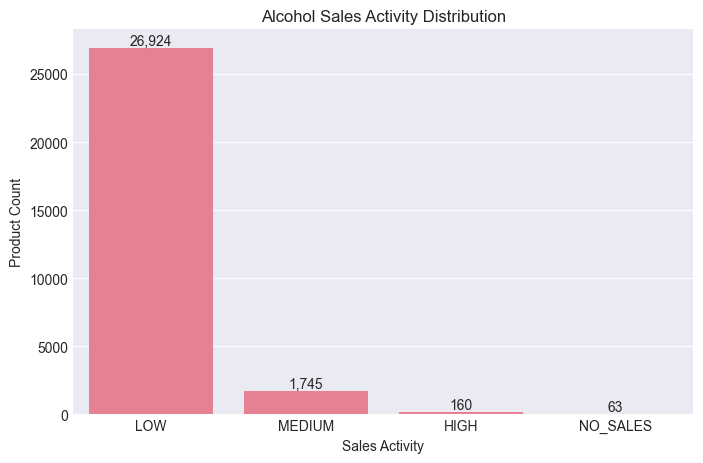

In [20]:
sales_activity_summary = alcohol_df["sales_activity"].value_counts().reset_index()

sales_activity_summary.columns = ["sales_activity", "count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=sales_activity_summary,
    x="sales_activity",
    y="count"
)

for i, value in enumerate(sales_activity_summary["count"]):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.title("Alcohol Sales Activity Distribution")
plt.xlabel("Sales Activity")
plt.ylabel("Product Count")

plt.show()

### Key Findings

- Most alcohol products fall under the LOW sales activity category.
- Medium sales activity products contribute a moderate share of product movement.
- Only a limited number of products generate HIGH sales activity.
- Very few products recorded NO_SALES activity.
- Alcohol product sales are heavily concentrated among low-moving products.

### Correlation Analysis

Correlation analysis is performed to identify:
- Relationship between retail sales, transfers, and warehouse sales
- Sales movement dependency across operational metrics
- Positive or negative sales associations

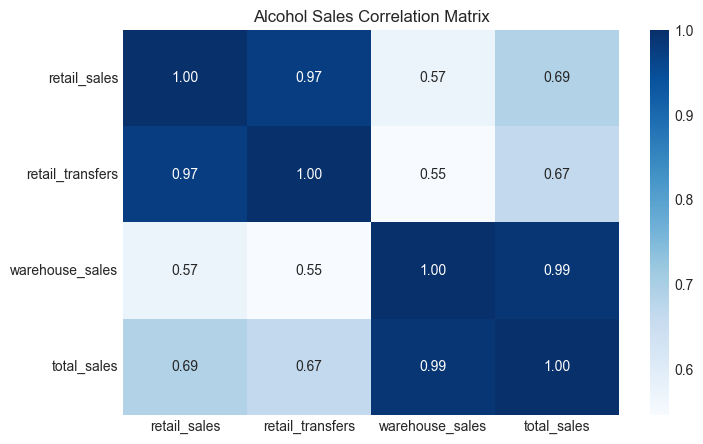

In [21]:
correlation_matrix = alcohol_df[["retail_sales", "retail_transfers", "warehouse_sales", "total_sales"]].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")

plt.title("Alcohol Sales Correlation Matrix")

plt.show()

### Key Findings

- Total sales show a very strong positive correlation with warehouse sales.
- Retail sales and retail transfers are also strongly positively correlated.
- Warehouse sales have moderate positive association with retail sales and retail transfers.
- Positive correlations indicate that increases in one sales metric generally align with increases in overall alcohol sales movement.
- The sales metrics are interconnected and collectively influence total alcohol sales performance.

# Alcohol Sales Dashboard

The following dashboard provides a consolidated overview of alcohol sales performance across:
- Sales trends
- Product category movement
- Bottle size behavior
- Supplier contribution
- Sales activity distribution
- Sales correlation patterns

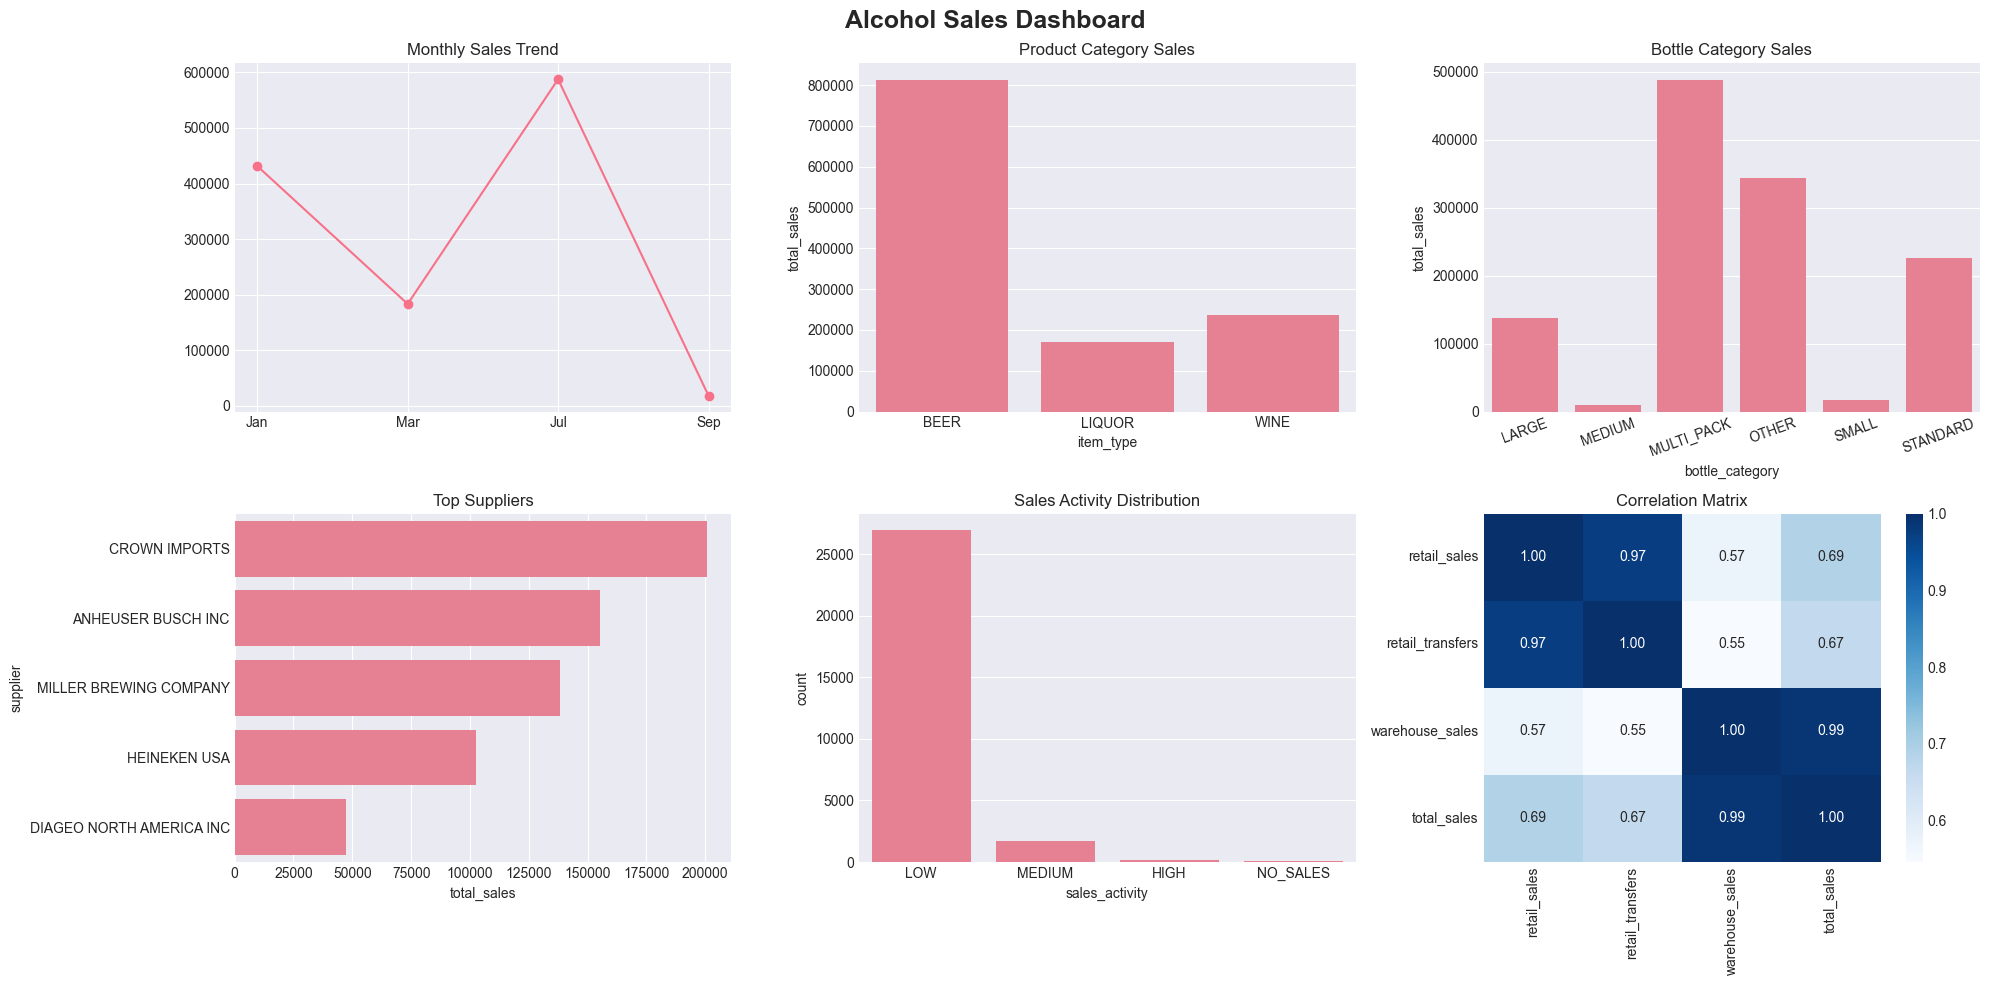

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

month_map = {1: "Jan", 3: "Mar", 7: "Jul", 9: "Sep"}

monthly_sales = alcohol_df.groupby("month")["total_sales"].sum().reset_index()
monthly_sales["month_name"] = monthly_sales["month"].map(month_map)

axes[0, 0].plot(monthly_sales["month_name"], monthly_sales["total_sales"], marker="o")
axes[0, 0].set_title("Monthly Sales Trend")


item_type_sales = alcohol_df.groupby("item_type")["total_sales"].sum().reset_index()

sns.barplot(data=item_type_sales, x="item_type", y="total_sales", ax=axes[0, 1])

axes[0, 1].set_title("Product Category Sales")


bottle_category_sales = alcohol_df.groupby("bottle_category")["total_sales"].sum().reset_index()

sns.barplot(data=bottle_category_sales, x="bottle_category", y="total_sales", ax=axes[0, 2])

axes[0, 2].set_title("Bottle Category Sales")
axes[0, 2].tick_params(axis="x", rotation=20)


top_suppliers = alcohol_df.groupby("supplier")["total_sales"].sum().sort_values(ascending=False).head(5).reset_index()

sns.barplot(data=top_suppliers, x="total_sales", y="supplier", ax=axes[1, 0])

axes[1, 0].set_title("Top Suppliers")


sales_activity_summary = alcohol_df["sales_activity"].value_counts().reset_index()

sales_activity_summary.columns = ["sales_activity", "count"]

sns.barplot(data=sales_activity_summary, x="sales_activity", y="count", ax=axes[1, 1])

axes[1, 1].set_title("Sales Activity Distribution")


correlation_matrix = alcohol_df[
    ["retail_sales", "retail_transfers", "warehouse_sales", "total_sales"]
].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f", ax=axes[1, 2])

axes[1, 2].set_title("Correlation Matrix")


plt.suptitle("Alcohol Sales Dashboard", fontsize=18, fontweight="bold")

plt.tight_layout()

os.makedirs("dashboards", exist_ok=True)

plt.savefig(
    "dashboards/alcohol_dashboard.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Alcohol Sales Dashboard Summary

- Beer products dominate overall alcohol sales performance and represent the strongest product segment in the dataset.
- Multi-pack and standard bottle categories contribute significantly to total alcohol sales, indicating strong customer preference for bundled and regular-sized packaging.
- Alcohol sales fluctuate across the available months, with July recording the highest sales movement.
- Sales contribution is highly concentrated among a few leading suppliers such as CROWN IMPORTS, ANHEUSER BUSCH INC, and MILLER BREWING COMPANY.
- Most alcohol products fall under the LOW sales activity category, while only a limited number of products generate high sales movement.
- Warehouse sales show a very strong positive relationship with total sales, indicating their major contribution toward overall alcohol product movement.
- Overall, the alcohol segment demonstrates strong demand concentration across specific product categories, packaging types, and key suppliers.

# Non-Alcohol Product Exploratory Data Analysis (EDA)

EDA is performed on non-alcohol products to analyze:
- Sales trends
- Package size behavior
- Supplier contribution
- Product movement patterns
- Sales distribution behavior

## Sales Trend Analysis

### Monthly & Quarterly Sales Trend Analysis

The available dataset contains sales records for selected months:
- January
- March
- July
- September

Sales trend analysis is performed to identify:
- Monthly sales fluctuations
- Quarter-wise sales movement
- Relative seasonal demand behavior
- Overall non-alcohol sales performance across available periods

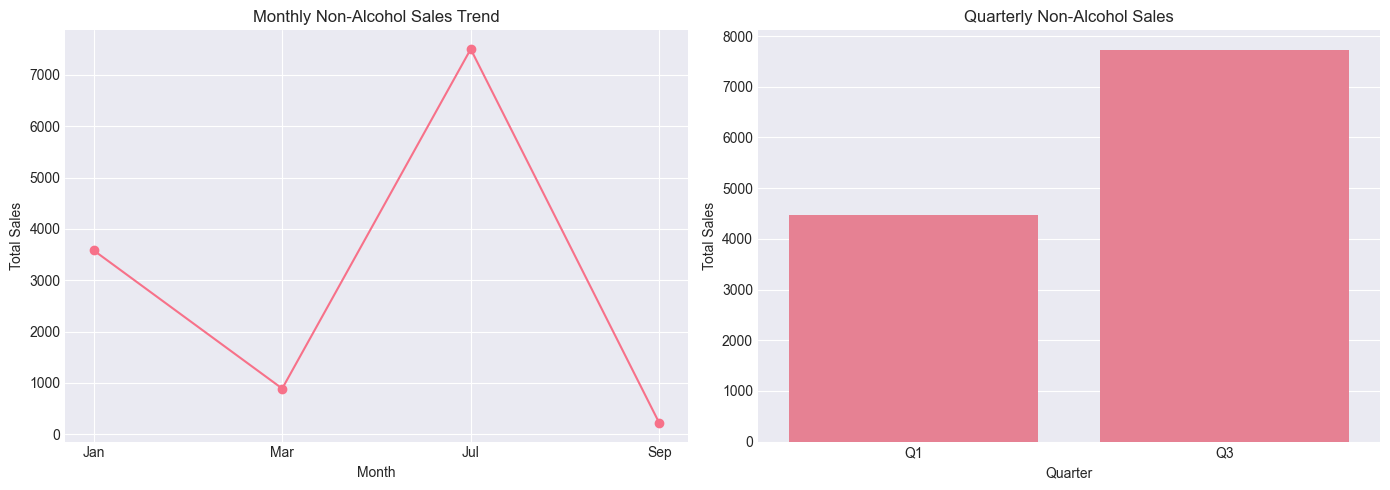

In [23]:
month_map = {1: "Jan", 3: "Mar", 7: "Jul", 9: "Sep"}

monthly_sales = non_alcohol_df.groupby("month")["total_sales"].sum().reset_index()

monthly_sales["month_name"] = monthly_sales["month"].map(month_map)

quarterly_sales = non_alcohol_df.groupby("quarter")["total_sales"].sum().reset_index()

quarterly_sales["quarter_name"] = "Q" + quarterly_sales["quarter"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_sales["month_name"], monthly_sales["total_sales"], marker="o")

axes[0].set_title("Monthly Non-Alcohol Sales Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Sales")

sns.barplot(data=quarterly_sales, x="quarter_name", y="total_sales", ax=axes[1])

axes[1].set_title("Quarterly Non-Alcohol Sales")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Sales")

plt.tight_layout()

plt.show()

### Key Findings

- July recorded the highest non-alcohol sales among the available months.
- September showed the lowest non-alcohol sales performance.
- Non-alcohol sales fluctuated noticeably across the recorded periods, indicating varying customer demand behavior.
- Quarter 3 generated higher non-alcohol sales compared to Quarter 1.
- The sales distribution suggests stronger non-alcohol product movement during the later recorded period.

## Package Size Behavior Analysis

### Non-Alcohol Package Size Analysis

Package size analysis is performed to understand:
- Customer packaging preferences
- Popular non-alcohol product sizes
- Product movement across package categories
- Demand concentration among different package formats

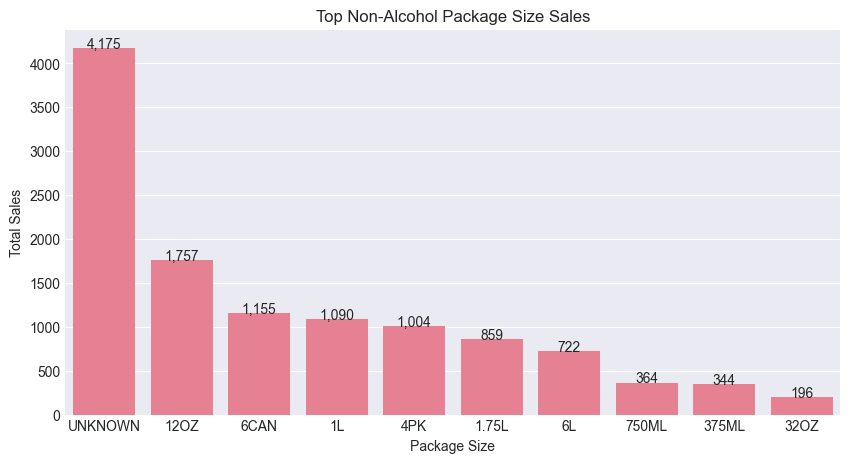

In [24]:
package_size_sales = non_alcohol_df.groupby("package_size")["total_sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=package_size_sales, x="package_size", y="total_sales")

for i, value in enumerate(package_size_sales["total_sales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center")

plt.title("Top Non-Alcohol Package Size Sales")

plt.xlabel("Package Size")
plt.ylabel("Total Sales")

plt.show()

### Key Findings

- Products with UNKNOWN package size generated the highest non-alcohol sales, indicating incomplete packaging information for several high-selling products.
- 12OZ package products recorded strong sales performance among clearly identified package sizes.
- 6CAN and 4PK package formats contributed significantly to non-alcohol product movement.
- Large package formats such as 1L and 1.75L also showed noticeable customer demand.
- Smaller package categories such as 375ML and 32OZ contributed comparatively lower sales volumes.
- The sales distribution indicates customer preference toward multi-unit and standard beverage packaging formats.

## Supplier Contribution Analysis

### Top Non-Alcohol Supplier Analysis

Supplier analysis is performed to identify:
- Major non-alcohol product suppliers
- Supplier-wise sales contribution
- Market concentration among suppliers
- High-performing non-alcohol distributors

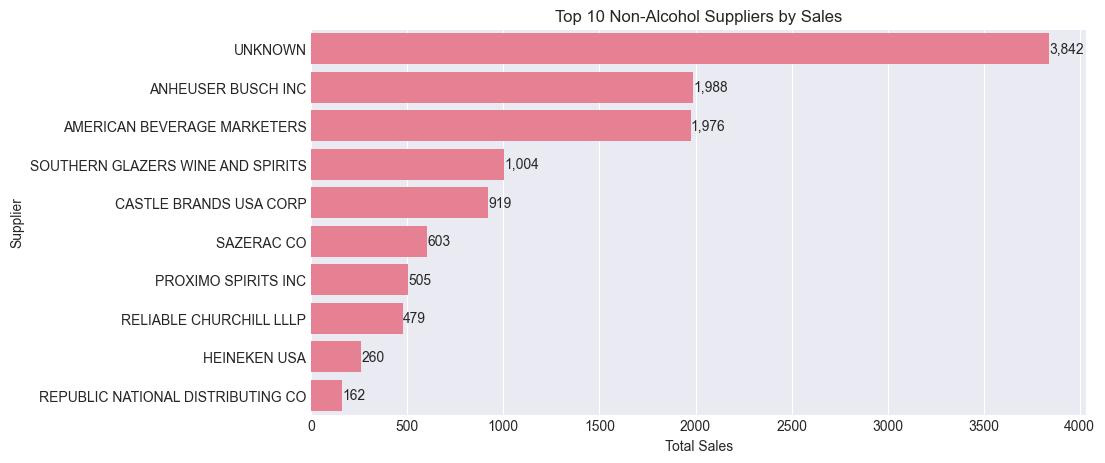

In [25]:
top_suppliers = non_alcohol_df.groupby("supplier")["total_sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=top_suppliers, x="total_sales", y="supplier")

for i, value in enumerate(top_suppliers["total_sales"]):
    ax.text(value, i, f"{value:,.0f}", va="center")

plt.title("Top 10 Non-Alcohol Suppliers by Sales")

plt.xlabel("Total Sales")
plt.ylabel("Supplier")

plt.show()

### Key Findings

- UNKNOWN supplier records generated the highest non-alcohol sales, indicating incomplete supplier information for several high-selling products.
- ANHEUSER BUSCH INC and AMERICAN BEVERAGE MARKETERS were the leading identified suppliers in the non-alcohol segment.
- Sales contribution is concentrated among a small group of suppliers.
- Mid-level suppliers contributed moderate non-alcohol sales movement compared to the top suppliers.
- The supplier distribution indicates uneven market contribution across non-alcohol product distributors.

## Sales Activity Analysis

### Non-Alcohol Sales Activity Distribution

Sales activity analysis is performed to understand:
- Product movement intensity
- Distribution of high and low selling products
- Overall non-alcohol product sales behavior
- Concentration of product demand levels

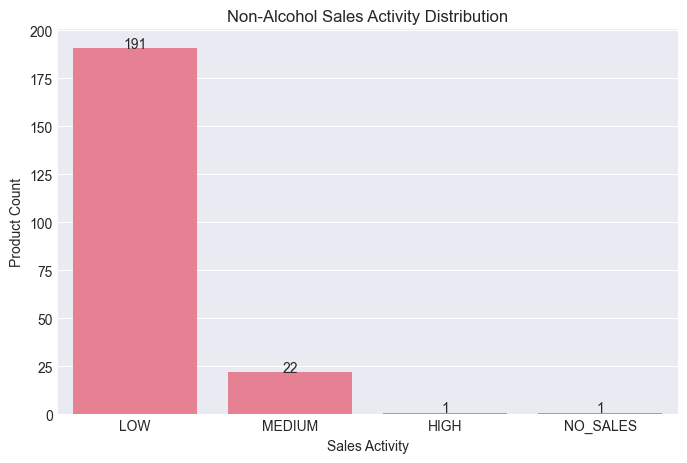

In [26]:
non_alcohol_df["sales_activity"] = non_alcohol_df["total_sales"].apply(classify_sales_activity)

sales_activity_summary = non_alcohol_df["sales_activity"].value_counts().reset_index()

sales_activity_summary.columns = ["sales_activity", "count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(data=sales_activity_summary, x="sales_activity", y="count")

for i, value in enumerate(sales_activity_summary["count"]):
    ax.text(i, value, f"{value:,}", ha="center")

plt.title("Non-Alcohol Sales Activity Distribution")

plt.xlabel("Sales Activity")
plt.ylabel("Product Count")

plt.show()

### Key Findings

- Most non-alcohol products fall under the MEDIUM sales activity category.
- LOW sales activity products also represent a significant share of the non-alcohol segment.
- A smaller group of products generates HIGH sales activity.
- Very few products recorded NO_SALES activity.
- Compared to the alcohol segment, non-alcohol products show relatively stronger medium-level product movement.
- The sales distribution indicates more balanced product demand across non-alcohol items.

## Correlation Analysis

### Non-Alcohol Sales Correlation Analysis

Correlation analysis is performed to understand relationships between:
- Retail sales
- Retail transfers
- Warehouse sales
- Overall total sales movement

This helps identify how different sales channels influence overall non-alcohol sales performance.

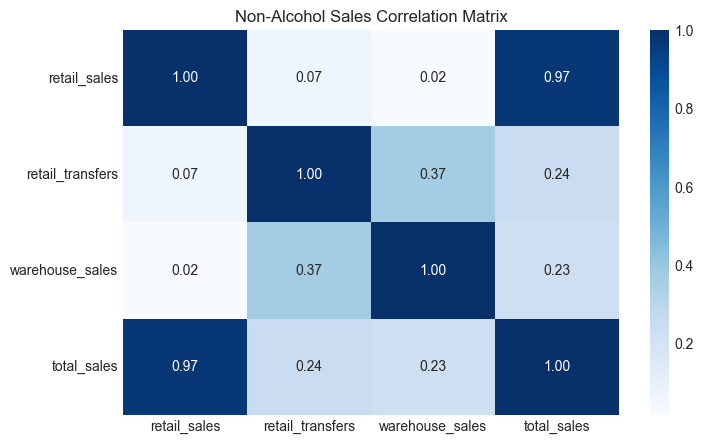

In [27]:
correlation_matrix = non_alcohol_df[
    ["retail_sales", "retail_transfers", "warehouse_sales", "total_sales"]
].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")

plt.title("Non-Alcohol Sales Correlation Matrix")

plt.show()

### Key Findings

- Total non-alcohol sales show a very strong positive correlation with retail sales.
- Retail transfers and warehouse sales have relatively weak correlation with total sales movement.
- Retail sales act as the primary driver of overall non-alcohol sales performance.
- Warehouse sales and retail transfers show only moderate association with each other.
- The correlation pattern indicates that non-alcohol product movement is mainly influenced by direct retail sales rather than warehouse distribution activity.

# Non-Alcohol Sales Dashboard

The following dashboard provides a consolidated overview of non-alcohol sales performance across:
- Sales trends
- Package size behavior
- Supplier contribution
- Sales activity distribution
- Sales correlation patterns

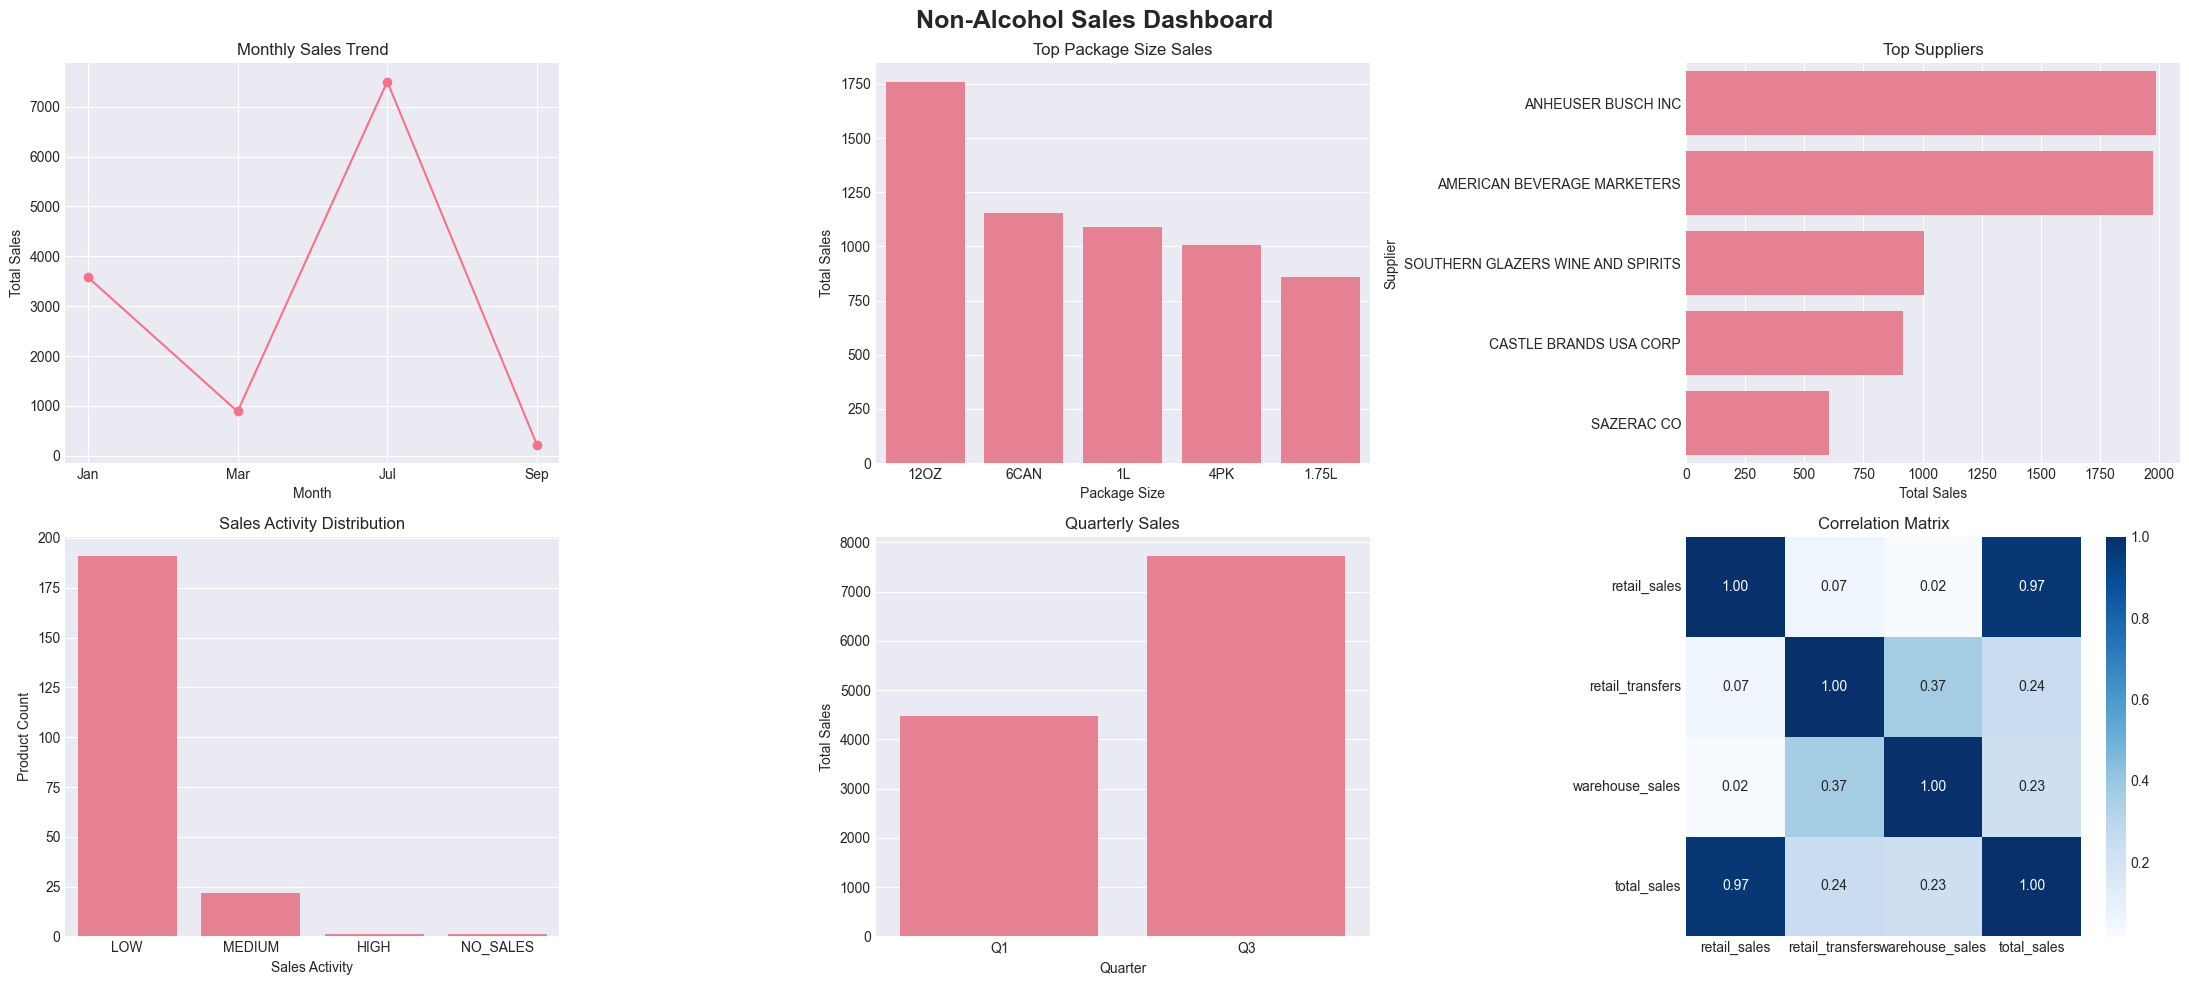

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))

month_map = {1: "Jan", 3: "Mar", 7: "Jul", 9: "Sep"}

monthly_sales = non_alcohol_df.groupby("month")["total_sales"].sum().reset_index()
monthly_sales["month_name"] = monthly_sales["month"].map(month_map)

axes[0, 0].plot(monthly_sales["month_name"], monthly_sales["total_sales"], marker="o")
axes[0, 0].set_title("Monthly Sales Trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Total Sales")


package_size_sales = (
    non_alcohol_df[non_alcohol_df["package_size"] != "UNKNOWN"]
    .groupby("package_size")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

sns.barplot(data=package_size_sales, x="package_size", y="total_sales", ax=axes[0, 1])
axes[0, 1].set_title("Top Package Size Sales")
axes[0, 1].set_xlabel("Package Size")
axes[0, 1].set_ylabel("Total Sales")


top_suppliers = (
    non_alcohol_df[
        non_alcohol_df["supplier"] != "UNKNOWN"
    ]
    .groupby("supplier")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

sns.barplot(data=top_suppliers, x="total_sales", y="supplier", ax=axes[0, 2])
axes[0, 2].set_title("Top Suppliers")
axes[0, 2].set_xlabel("Total Sales")
axes[0, 2].set_ylabel("Supplier")


sales_activity_summary = non_alcohol_df["sales_activity"].value_counts().reset_index()
sales_activity_summary.columns = ["sales_activity", "count"]

sns.barplot(data=sales_activity_summary, x="sales_activity", y="count", ax=axes[1, 0])
axes[1, 0].set_title("Sales Activity Distribution")
axes[1, 0].set_xlabel("Sales Activity")
axes[1, 0].set_ylabel("Product Count")


quarterly_sales = non_alcohol_df.groupby("quarter")["total_sales"].sum().reset_index()
quarterly_sales["quarter_name"] = "Q" + quarterly_sales["quarter"].astype(str)

sns.barplot(data=quarterly_sales, x="quarter_name", y="total_sales", ax=axes[1, 1])
axes[1, 1].set_title("Quarterly Sales")
axes[1, 1].set_xlabel("Quarter")
axes[1, 1].set_ylabel("Total Sales")


correlation_matrix = non_alcohol_df[
    ["retail_sales", "retail_transfers", "warehouse_sales", "total_sales"]
].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f", ax=axes[1, 2])
axes[1, 2].set_title("Correlation Matrix")


plt.suptitle("Non-Alcohol Sales Dashboard", fontsize=18, fontweight="bold")

plt.tight_layout()

plt.savefig(
    "dashboards/non_alcohol_dashboard.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Non-Alcohol Sales Dashboard Summary

- July recorded the highest non-alcohol sales, while September showed the lowest sales among the available months.
- Quarter 3 outperformed Quarter 1, indicating stronger non-alcohol product movement in the later recorded period.
- Among identified package sizes, 12OZ, 6CAN, 1L, 4PK, and 1.75L contributed strongly to non-alcohol sales.
- ANHEUSER BUSCH INC and AMERICAN BEVERAGE MARKETERS were the leading identified suppliers in the non-alcohol segment.
- Most non-alcohol products fall under MEDIUM and LOW sales activity, showing relatively balanced product movement.
- Total sales are strongly driven by retail sales, while warehouse sales and transfers have weaker influence.
- Overall, non-alcohol sales are mainly influenced by direct retail demand, selected package formats, and a small group of key suppliers.

# Operational Product Exploratory Data Analysis (EDA)

EDA is performed on operational products to analyze:
- Operational movement trends
- Package and keg size behavior
- Supplier contribution
- Operational activity distribution
- Movement relationships across operational metrics

## Operational Movement Trend Analysis

### Monthly & Quarterly Operational Movement Analysis

The available dataset contains operational movement records for selected months:
- January
- March
- July
- September

Operational movement analysis is performed to identify:
- Monthly operational fluctuations
- Quarter-wise operational movement
- Seasonal operational activity behavior
- Overall operational product movement trends

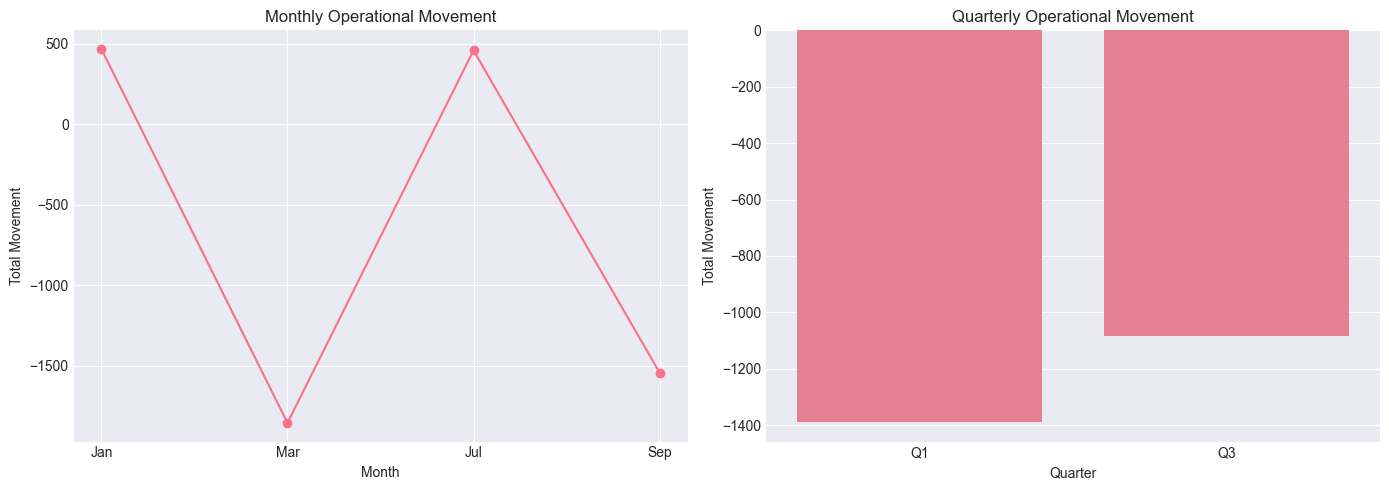

In [29]:
month_map = {1: "Jan", 3: "Mar", 7: "Jul", 9: "Sep"}

monthly_operations = operational_df.groupby("month")["total_sales"].sum().reset_index()

monthly_operations["month_name"] = monthly_operations["month"].map(month_map)

quarterly_operations = operational_df.groupby("quarter")["total_sales"].sum().reset_index()

quarterly_operations["quarter_name"] = "Q" + quarterly_operations["quarter"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    monthly_operations["month_name"],
    monthly_operations["total_sales"],
    marker="o"
)

axes[0].set_title("Monthly Operational Movement")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Movement")


sns.barplot(
    data=quarterly_operations,
    x="quarter_name",
    y="total_sales",
    ax=axes[1]
)

axes[1].set_title("Quarterly Operational Movement")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Movement")

plt.tight_layout()

plt.show()

### Key Findings

- Operational movement fluctuated significantly across the available months.
- January and July recorded positive operational movement, while March and September showed strong negative movement.
- Quarter 1 and Quarter 3 both recorded negative overall operational movement.
- Negative movement values likely indicate operational returns, keg reversals, inventory adjustments, or dunnage-related transactions.
- Operational datasets behave differently from alcohol and non-alcohol sales datasets due to the presence of reverse inventory movement records.
- The operational segment reflects inventory and logistics activity rather than direct customer sales demand.

## Package & Keg Size Behavior Analysis

### Operational Package Size Analysis

Operational package analysis is performed to understand:
- Keg size distribution
- Operational packaging movement
- Frequently used operational package formats
- Inventory and logistics movement patterns

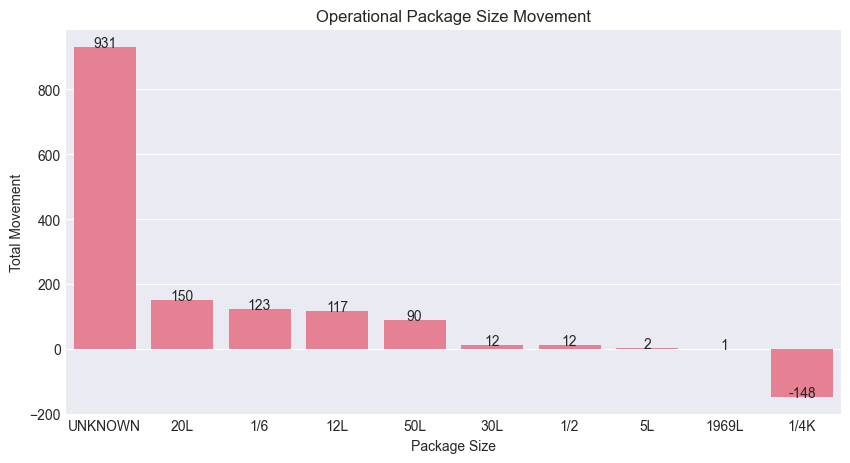

In [30]:
package_size_summary = operational_df.groupby("package_size")["total_sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=package_size_summary, x="package_size", y="total_sales")

for i, value in enumerate(package_size_summary["total_sales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center")

plt.title("Operational Package Size Movement")

plt.xlabel("Package Size")
plt.ylabel("Total Movement")

plt.show()

### Key Findings

- UNKNOWN package size records generated the highest operational movement, indicating incomplete operational packaging information for several records.
- 20L, 1/6, 12L, and 50L package formats contributed positively to operational movement.
- The 1/4K package category recorded negative movement, likely representing returns, keg reversals, or inventory adjustments.
- Most operational package categories showed relatively low movement volumes compared to UNKNOWN records.
- Operational package movement reflects inventory logistics activity rather than direct customer purchasing behavior.
- Keg-based package formats dominate operational movement across the dataset.

## Supplier Contribution Analysis

### Operational Supplier Analysis

Supplier analysis is performed to identify:
- Major operational suppliers
- Supplier-wise operational movement
- Inventory and logistics concentration
- Operational contribution across suppliers

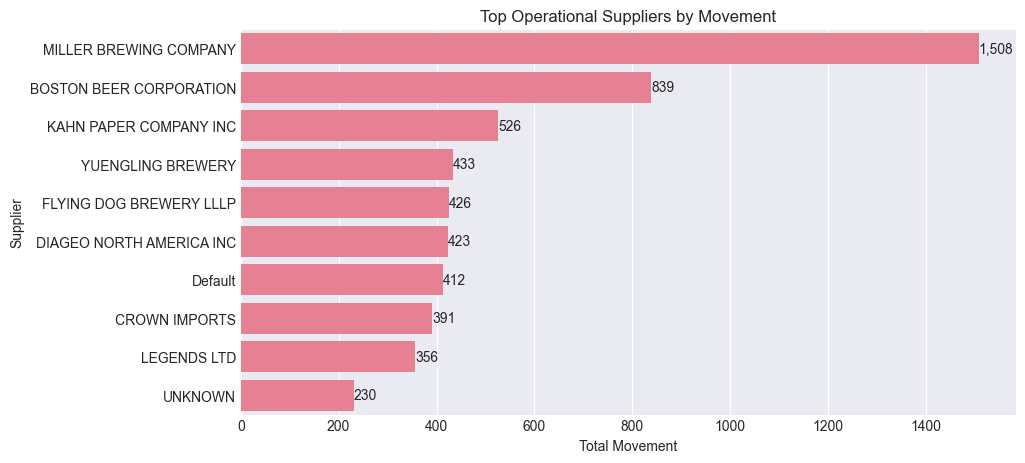

In [31]:
top_operational_suppliers = operational_df.groupby("supplier")["total_sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=top_operational_suppliers, x="total_sales", y="supplier")

for i, value in enumerate(top_operational_suppliers["total_sales"]):
    ax.text(value, i, f"{value:,.0f}", va="center")

plt.title("Top Operational Suppliers by Movement")

plt.xlabel("Total Movement")
plt.ylabel("Supplier")

plt.show()

### Key Findings

- MILLER BREWING COMPANY recorded the highest operational movement among all suppliers by a significant margin.
- BOSTON BEER CORPORATION and KAHN PAPER COMPANY INC were also major contributors to operational product movement.
- Operational movement is concentrated among a limited group of suppliers.
- Brewery-related suppliers dominate operational movement, indicating strong keg and inventory handling activity.
- Suppliers such as CROWN IMPORTS, LEGENDS LTD, and DIAGEO NORTH AMERICA INC contributed moderate operational movement.
- UNKNOWN and Default supplier records indicate the presence of operational entries with incomplete supplier mapping.
- The supplier distribution reflects backend logistics, inventory support, and operational warehouse activities rather than direct retail sales performance.

## Operational Activity Analysis

### Operational Activity Distribution

Operational activity analysis is performed to understand:
- Distribution of operational movement intensity
- High and low operational activity products
- Inventory movement behavior
- Operational logistics concentration

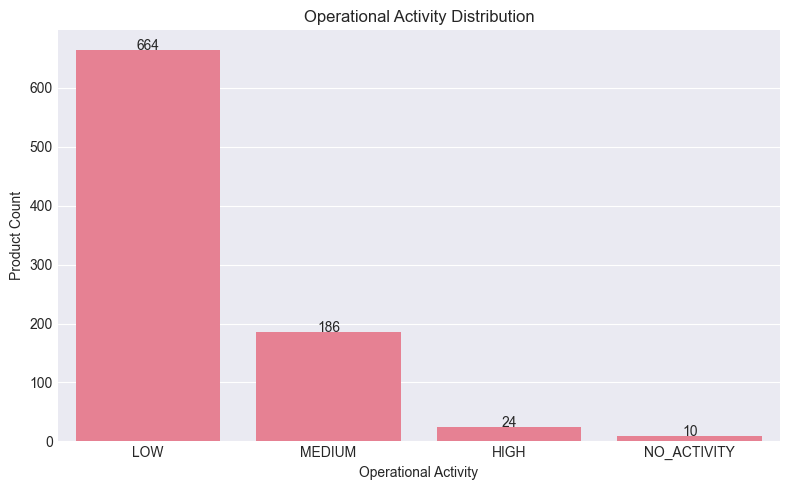

In [32]:
from IPython.display import display, HTML

display(HTML("""
<style>
div.output_scroll {
    height: auto !important;
    max-height: none !important;
}
</style>
"""))

operational_activity_summary = operational_df["operational_activity"].value_counts().reset_index()

operational_activity_summary.columns = ["operational_activity", "count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=operational_activity_summary,
    x="operational_activity",
    y="count"
)

for i, value in enumerate(operational_activity_summary["count"]):
    ax.text(i, value, f"{value:,}", ha="center")

plt.title("Operational Activity Distribution")

plt.xlabel("Operational Activity")
plt.ylabel("Product Count")

plt.tight_layout()

plt.show()

### Key Findings

- Most operational products fall under the LOW operational activity category.
- Medium operational activity products contribute a smaller share of overall operational movement.
- Only a limited number of operational products generate HIGH activity movement.
- Very few products recorded NO_ACTIVITY movement.
- Operational movement is highly concentrated among low-moving inventory and logistics products.
- The operational segment primarily reflects warehouse handling, inventory adjustments, keg movement, and support operations rather than direct customer purchasing behavior.

## Correlation Analysis

### Operational Movement Correlation Analysis

Correlation analysis is performed to understand relationships between:
- Retail sales
- Retail transfers
- Warehouse sales
- Overall operational movement

This helps identify how different operational channels influence total operational movement.

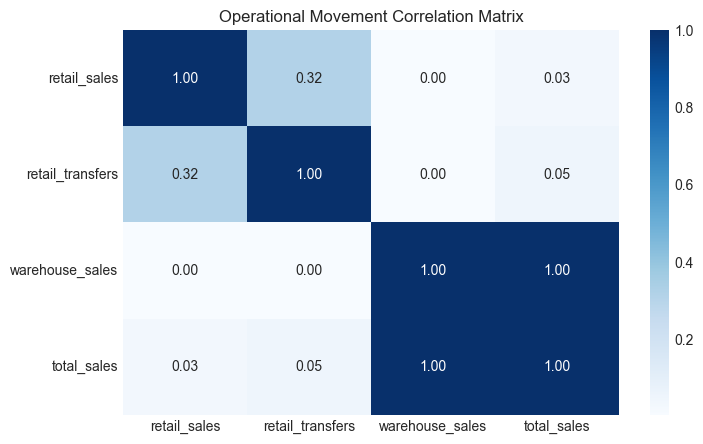

In [33]:
correlation_matrix = operational_df[
    ["retail_sales", "retail_transfers", "warehouse_sales", "total_sales"]
].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")

plt.title("Operational Movement Correlation Matrix")

plt.show()

### Key Findings

- Total operational movement shows an almost perfect positive correlation with warehouse sales.
- Retail sales and retail transfers have very weak relationships with overall operational movement.
- Warehouse activity acts as the primary driver of operational product movement.
- Retail sales and retail transfers show only mild positive association with each other.
- The operational segment is heavily influenced by inventory logistics and warehouse handling processes rather than direct customer sales activity.
- Operational datasets primarily reflect backend inventory operations, keg handling, and supply-chain movement behavior.

# Operational Movement Dashboard

The following dashboard provides a consolidated overview of operational product movement across:
- Operational movement trends
- Package and keg size behavior
- Supplier contribution
- Operational activity distribution
- Operational movement correlation patterns

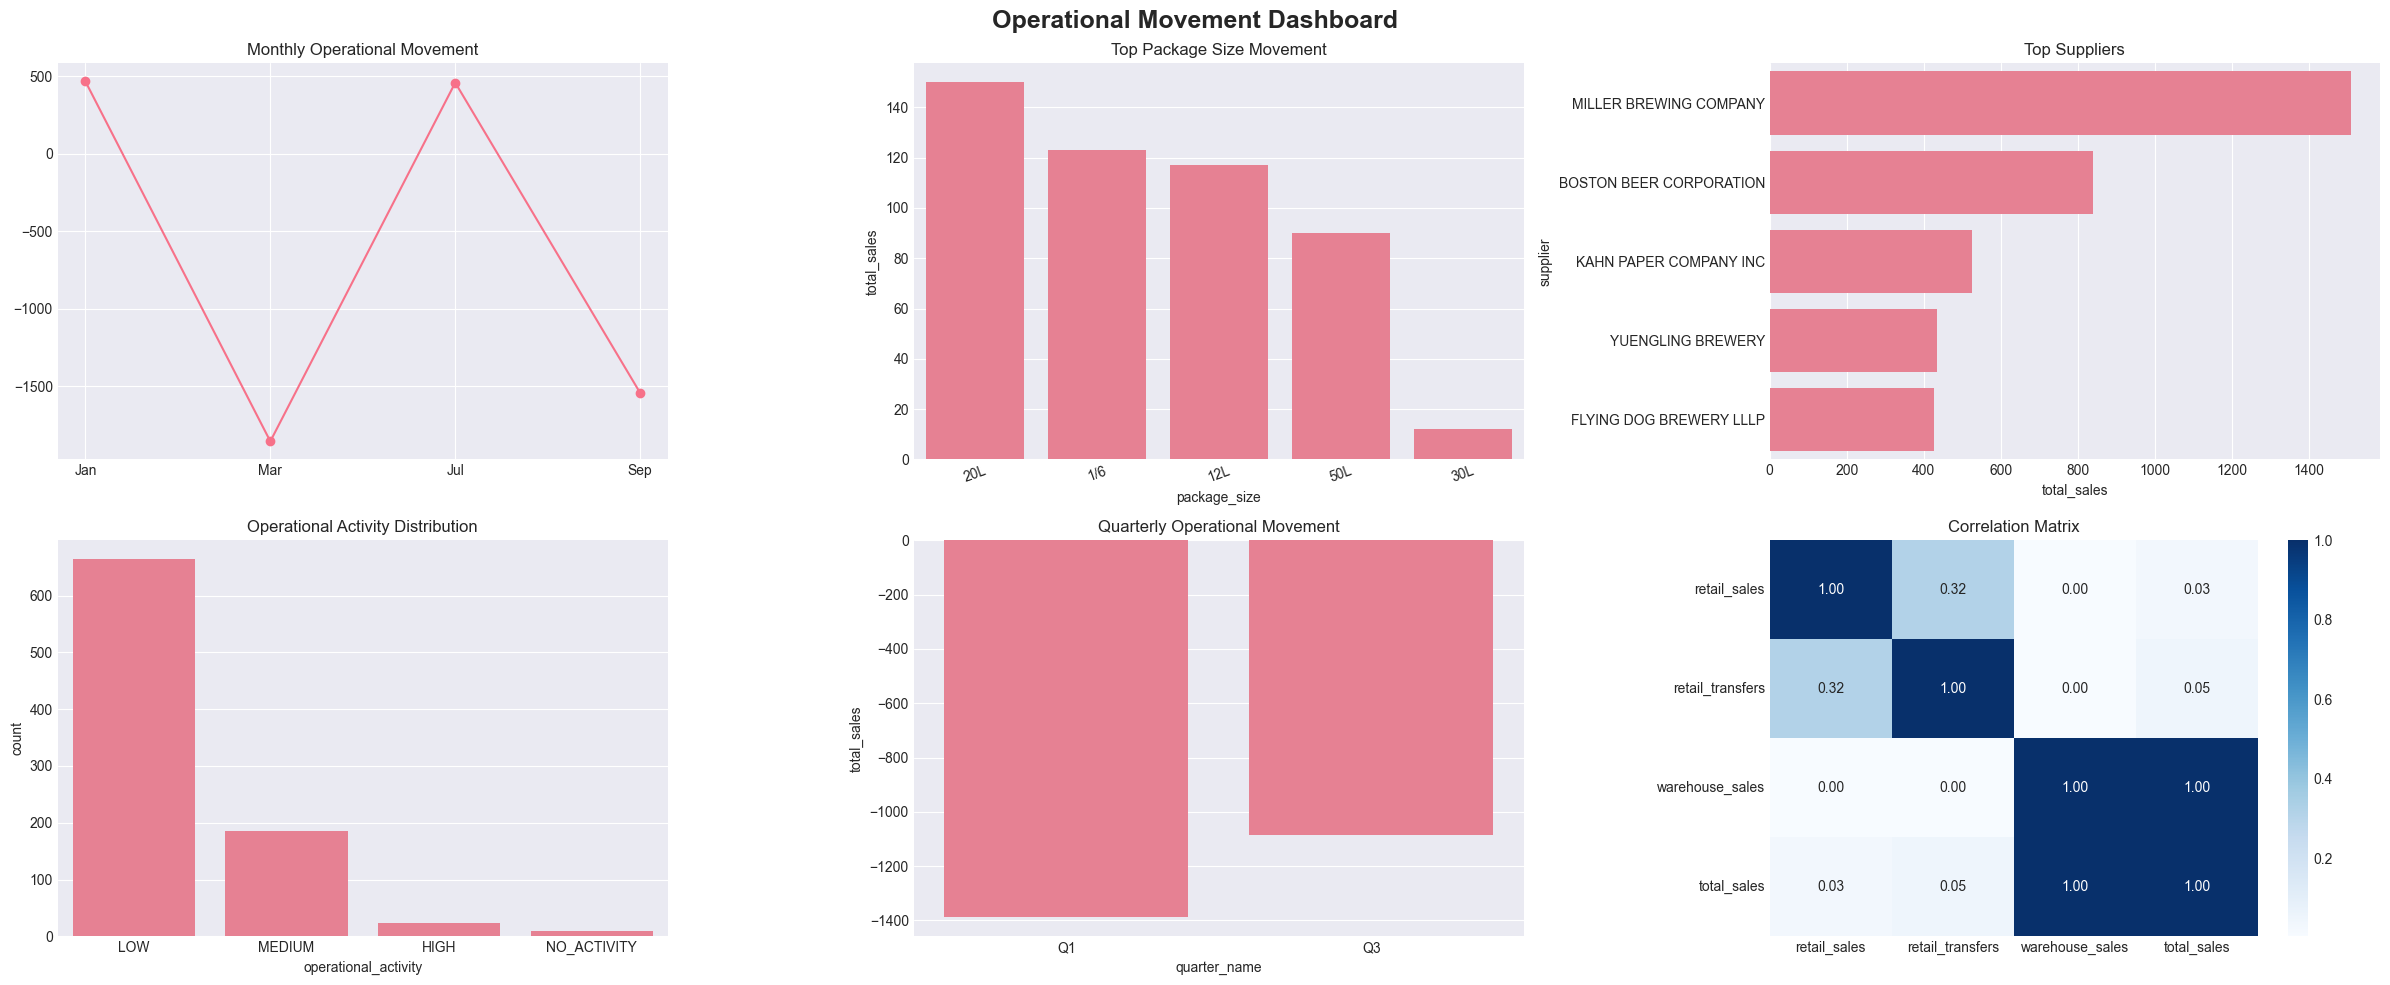

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(24, 10))

month_map = {1:"Jan", 3:"Mar", 7:"Jul", 9:"Sep"}

monthly_operations = operational_df.groupby("month")["total_sales"].sum().reset_index()
monthly_operations["month_name"] = monthly_operations["month"].map(month_map)

axes[0,0].plot(monthly_operations["month_name"], monthly_operations["total_sales"], marker="o")
axes[0,0].set_title("Monthly Operational Movement")


package_size_summary = operational_df[operational_df["package_size"] != "UNKNOWN"].groupby("package_size")["total_sales"].sum().sort_values(ascending=False).head(5).reset_index()

sns.barplot(data=package_size_summary, x="package_size", y="total_sales", ax=axes[0,1])
axes[0,1].set_title("Top Package Size Movement")
axes[0,1].tick_params(axis="x", rotation=20)


top_operational_suppliers = operational_df.groupby("supplier")["total_sales"].sum().sort_values(ascending=False).head(5).reset_index()

sns.barplot(data=top_operational_suppliers, x="total_sales", y="supplier", ax=axes[0,2])
axes[0,2].set_title("Top Suppliers")


operational_activity_summary = operational_df["operational_activity"].value_counts().reset_index()
operational_activity_summary.columns = ["operational_activity", "count"]

sns.barplot(data=operational_activity_summary, x="operational_activity", y="count", ax=axes[1,0])
axes[1,0].set_title("Operational Activity Distribution")


quarterly_operations = operational_df.groupby("quarter")["total_sales"].sum().reset_index()
quarterly_operations["quarter_name"] = "Q" + quarterly_operations["quarter"].astype(str)

sns.barplot(data=quarterly_operations, x="quarter_name", y="total_sales", ax=axes[1,1])
axes[1,1].set_title("Quarterly Operational Movement")


correlation_matrix = operational_df[
    ["retail_sales", "retail_transfers", "warehouse_sales", "total_sales"]
].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f", ax=axes[1,2])
axes[1,2].set_title("Correlation Matrix")


plt.suptitle("Operational Movement Dashboard", fontsize=18, fontweight="bold")

plt.tight_layout()

plt.savefig(
    "dashboards/operational_dashboard.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Operational Movement Dashboard Summary

- Operational movement fluctuated significantly across the available months, with March and September recording strong negative movement.
- Quarter 1 and Quarter 3 both showed overall negative operational movement due to inventory reversals and warehouse adjustments.
- Keg-based package formats such as 20L, 1/6, 12L, and 50L contributed most of the operational movement.
- MILLER BREWING COMPANY and BOSTON BEER CORPORATION were the leading contributors to operational product movement.
- Most operational products fall under the LOW operational activity category, indicating limited movement across operational inventory items.
- Total operational movement is heavily driven by warehouse sales activity, showing strong dependency on backend inventory and logistics operations.
- Operational datasets primarily represent inventory handling, keg movement, warehouse transfers, and support supply-chain activities rather than direct customer sales behavior.

# Final Business Conclusion

This project analyzed alcohol, non-alcohol, and operational retail datasets to understand sales trends, supplier contribution, packaging behavior, and operational inventory movement.

The analysis involved:
- Data cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
- Dashboard visualization
- Business insight generation

The project successfully transformed raw retail transaction data into meaningful analytical insights suitable for business reporting and operational decision-making.

---

## Final Business Insights

- Beer products dominated overall alcohol sales performance across the dataset.
- Multi-pack and standard packaging formats generated strong product movement.
- Non-alcohol products showed relatively stable and retail-driven purchasing behavior.
- Supplier contribution across all segments was concentrated among a limited number of major distributors.
- Operational datasets highlighted backend inventory handling, warehouse movement, and logistics activity.
- Warehouse sales strongly influenced overall operational and alcohol product movement.